# Random Forest - HR Employee Attrition 

**Goal** Train a Random Forest classifier to predict employee attrition, evaluate it, and export the model + preprocessing pipeline so DiCE can generate counterfactual explanations.

----

Outputs saved for Dice:
- *feature_names.pkl* : Ordered list of features names
- *label_encoders.pkl*: LabelEncoders for categorical features
- *random_forest.pkl* : trained model
- *scaler.pkl*: StandardScaler fitted on training data

# 1. Data Load
## 1.1. Paths
Loads project paths from utils.py (DATA = data/processed/, RF = data/models/RF/) and reuses the shared SEED constant to guarantee reproducibility across notebooks.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from utils import get_project_paths
from utils import SEED_DICE as SEED

paths       = get_project_paths()
DATA        = paths["DATA"]
MODELS_PATH = paths["RF"]

print(f'Preprocessed: {DATA}')
print(f'Models out:   {MODELS_PATH}')

Preprocessed: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
Models out:   c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF


## 1.2.Imports
If you don't have the packages below in your environment, uncomment the lines below and run this notebook for the first time. If you have everything, ignore this part. 

In [2]:
'''
%pip install numpy pandas matplotlib scikit-learn
'''

'\n%pip install numpy pandas matplotlib scikit-learn\n'

In [3]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1.3.Load Preprocessed Data
Loads the train,validation, and test splits did in notebook 1.Preprocessing.ipynb. Along with the fitted scaler, feature names, and label encoders, we will re-export this with the model so DiCE can reconstruct the same pipeline.

In [4]:
X_train = np.load(os.path.join(DATA,'X_train.npy'))
X_val   = np.load(os.path.join(DATA,'X_val.npy'))
X_test  = np.load(os.path.join(DATA,'X_test.npy'))

y_train = np.load(os.path.join(DATA,'y_train.npy'))
y_val   = np.load(os.path.join(DATA,'y_val.npy'))
y_test  = np.load(os.path.join(DATA,'y_test.npy'))

# train + val for hyperparameter search CV
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

with open(os.path.join(DATA, 'scaler.pkl'),         'rb') as f: scaler         = pickle.load(f)
with open(os.path.join(DATA, 'feature_names.pkl'),  'rb') as f: feature_names  = pickle.load(f)
with open(os.path.join(DATA, 'label_encoders.pkl'), 'rb') as f: label_encoders = pickle.load(f)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    |  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nFeatures ({len(feature_names)}): {feature_names}')
print(f'\nClass distribution in train — 0 (No): {(y_train==0).sum()} | 1 (Yes): {(y_train==1).sum()}')

X_train: (1029, 30)  |  y_train: (1029,)
X_val:   (220, 30)    |  y_val:   (220,)
X_test:  (221, 30)   |  y_test:  (221,)

Features (30): ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Class distribution in train — 0 (No): 863 | 1 (Yes): 166


# 2. Random Forest 
## 2.1. Hyperparameter Search
We look for the best parameter using RandomizedSearchCV on train+val, with 5-fold stratified CV.

The Stratified folds preserve the +/- 17% minority class ratio in every split... which is really useful for imbalanced data.

We set n_iter = 30 to select 30 random combinations. If you want, you can raise this number, but we like 30; it's a good balance between exploration time and execution. 5-10mnts.


In [5]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight':      [
        'balanced',
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 8},
    ],
}

base_rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

# With this, we make sure we always work with the minority class
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) 

# RandomizedSearchCV for hyperparameter tuning with recall as the scoring metric
# it will be faster thant GridSearchCV
search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit = True, # When we found the best parameters we train the model with it, we dont need the .fit()
)

search.fit(X_trainval, y_trainval) # Since with cv we create the splits, we don't need the division between train and validation, so we merge it 
print(f'Best hyperparameters: {search.best_score_:.4f} | {search.best_params_}')
rf = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters: 0.4080 | {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 20, 'class_weight': {0: 1, 1: 8}}


## 2.2. Optimal Threshold Search
The default threshold (0.5) assumes equal misclassification costs and balanced classes; neither holds here. We scan all thresholds on the validation set  and pick the one that maximises F1 for Attrition=1.

We use the validation set (not test) to avoid leaking threshold information into the final evaluation.

✅ Optimal threshold on validation set: 0.489
   Best F1 (Attrition=1) on val:       0.9333
Dont forget to save this value in utils.py like THRESHOLD_RF = 0.489 . The registered value now is 0.489


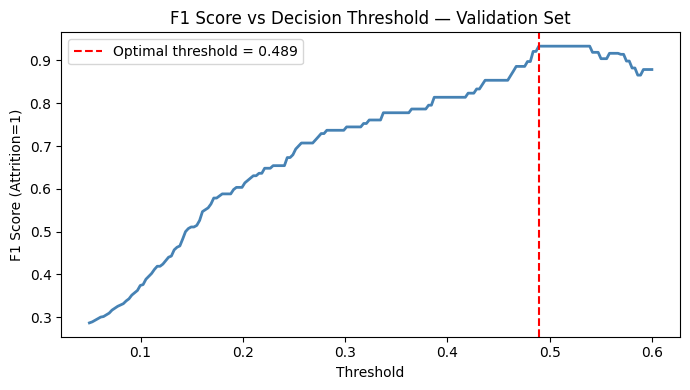

In [ ]:
y_val_proba = rf.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05,0.60,200)
f1_scores = [f1_score(y_val, (y_val_proba >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds
]

THRESHOLD = thresholds[np.argmax(f1_scores)]
best_f1_val = max(f1_scores)

print(f'✅ Optimal threshold on validation set: {THRESHOLD:.3f}')
print(f'   Best F1 (Attrition=1) on val:       {best_f1_val:.4f}')
from utils import THRESHOLD_RF
print(f"Dont forget to save this value in utils.py like THRESHOLD_RF = {THRESHOLD:.3f} . The registered value now is {THRESHOLD_RF}")
# Plot F1 vs Threshold
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
ax.axvline(THRESHOLD, color='red', linestyle='--', label=f'Optimal threshold = {THRESHOLD:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score (Attrition=1)')
ax.set_title('F1 Score vs Decision Threshold — Validation Set')
ax.legend()
plt.tight_layout()
plt.show()

## 2.3. ROC & Precision-Recall Curves
We use the validation set to measure how well the model can distinguish between classes, regardless of the threshold chosen.

We use ROC-AUC, which measures the probability that the model ranks a positive example higher than a negative one. However, since our classes are imbalanced, this metric can be overly optimistic. We use it as a baseline to spot potential issues.

PR-AUC is more suitable for our problem because we want to focus on the minority class and avoid models that have high recall only due to low precision.

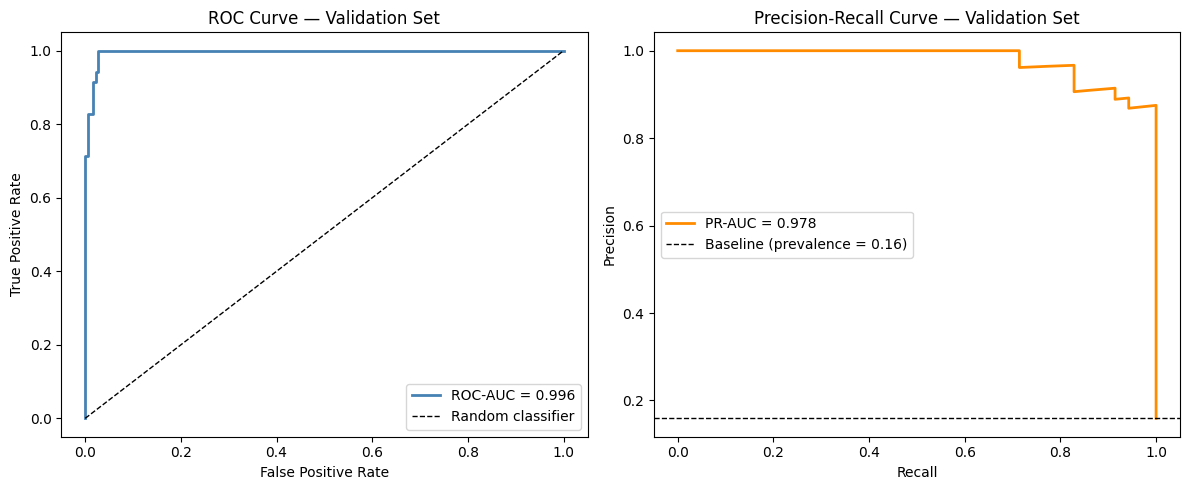

ROC-AUC:  0.9958
PR-AUC:   0.9781


In [7]:
# ROC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc     = auc(fpr, tpr)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc               = average_precision_score(y_val, y_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set')
axes[0].legend()

# PR curve
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].axhline(
    y_val.mean(), color='k', linestyle='--', lw=1,
    label=f'Baseline (prevalence = {y_val.mean():.2f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Validation Set')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'PR-AUC:   {pr_auc:.4f}')

## 2.4. Test Evaluation
Following our principal problem, the class imbalance, We set F1 for Attrition=1 as ore primary metric:
- So we dont mislead with accuracy alone (we can archive the 83% by predicing all-No)
- Weight F1 is dominated by the majority class


In [8]:
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

acc          = accuracy_score(y_test, y_test_pred)
f1_weighted  = f1_score(y_test, y_test_pred, average='weighted')
f1_attrition = f1_score(y_test, y_test_pred, pos_label=1)

print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))
print(f'Accuracy:          {acc:.3f}')
print(f'F1 (weighted):     {f1_weighted:.3f}')
print(f'F1 (Attrition=1):  {f1_attrition:.3f}  ← primary metric')

              precision    recall  f1-score   support

      No (0)       0.89      0.94      0.91       185
     Yes (1)       0.56      0.39      0.46        36

    accuracy                           0.85       221
   macro avg       0.72      0.66      0.69       221
weighted avg       0.83      0.85      0.84       221

Accuracy:          0.851
F1 (weighted):     0.839
F1 (Attrition=1):  0.459  ← primary metric


## 2.5. Confusion Matrix
By setting the threshold below 0.5, we accept more false positives, meaning some employees are flagged as leaving even though they stay. This helps reduce false negatives, where employees who actually leave go undetected. We found the best balance using the validation set.

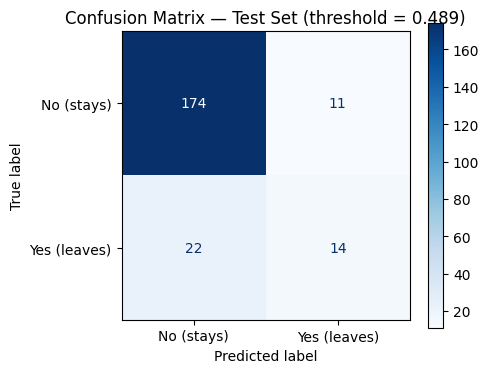

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['No (stays)', 'Yes (leaves)'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix — Test Set (threshold = {THRESHOLD:.3f})')
plt.tight_layout()
plt.show()

## 2.6. Feature Importances MDI
Mean Decrease in Impurity measures the average reduction in Gini impurity across all trees. A higher value means the model depends more on that feature when making splits.

One limitation is that MDI can overestimate the importance of features with many unique values.
It can also underestimate the importance of features that are highly correlated with others. Use these results as a qualitative guide, not as an absolute ranking.

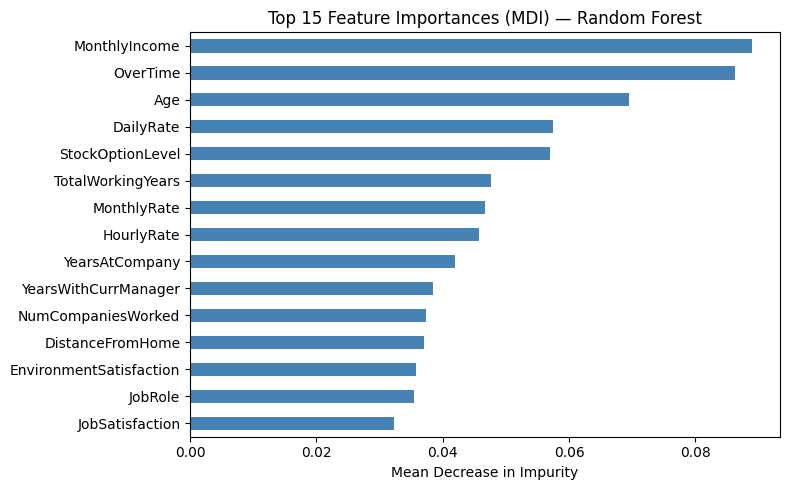

In [10]:
importances = pd.Series(rf.feature_importances_, index=feature_names)
top15       = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importances (MDI) — Random Forest')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

# 3. Save Artifacts for Dice
Saves all the objects that DiCE needs to rebuild the setup
This ensures the preprocessing pipeline can be exactly recreated and valid counterfactuals can be generated.

- random_forest.pkl: the best estimator found by RandomizedSearchCV
- scaler.pkl: StandardScaler fitted on X_train
- feature_names.pkl: ordered list of features (column order is important for DiCE)
- label_encoders.pkl: LabelEncoders for each categorical feature

In [11]:
artifacts = {
    'random_forest.pkl':  rf,
    'feature_names.pkl':  feature_names,
    'label_encoders.pkl': label_encoders,
    'scaler.pkl':         scaler,
}

for filename, obj in artifacts.items():
    path = os.path.join(MODELS_PATH, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ Saved: {path}')

print(f'\n📦 All artifacts saved.')
print(f'   Best hyperparams: {search.best_params_}')
print(f'   Optimal threshold: {THRESHOLD:.3f}')

✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF\random_forest.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF\feature_names.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF\label_encoders.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF\scaler.pkl

📦 All artifacts saved.
   Best hyperparams: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 20, 'class_weight': {0: 1, 1: 8}}
   Optimal threshold: 0.489


## 3.1. Optional Updload to Google Drive

In [12]:
try:
    from google.colab import drive as _drive
    _drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_MODELS = '/content/drive/MyDrive/Current_Trends_in_AI/models'
    os.makedirs(DRIVE_MODELS, exist_ok=True)
    for fname in ['random_forest.pkl', 'scaler.pkl', 'feature_names.pkl', 'label_encoders.pkl']:
        shutil.copy(os.path.join(MODELS_PATH, fname), os.path.join(DRIVE_MODELS, fname))
        print(f'☁️  {fname}')
else:
    print('Not in Colab — skipping Drive upload.')

Not in Colab — skipping Drive upload.
